Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
RUN PARAMS | N_target=15000, batch_size=1000, max_in_flight=8
 Max Capture Time=100000000 yr, Sphere=250.000 au, Lifetime Time=-1000000 times mean capture time
Number density of ISOs=1.000e-01 au^-3
Velocity Parameters: Sigma=5.510 au/yr, V max=0.750 au/yr
Collisions=True
Sun: Mass=1.048e+03 M_J, Radius=0.00465 au
Jupiter: Mass=1.000e+00 M_J, Semimajor axis=5.204e+00 au, Position=[ 3.99487484  2.94070924 -0.10146064], Velocity=[-1.66706807  2.35202321  0.02757877], Radius=0.000478
G=3.768e-02 au^3 M_J^-1 yr^-1
Dask dashboard: http://localhost:8787/


Captured ISOs:   0%|          | 0/15000 [00:00<?, ?it/s]

Attempted ISOs: 0it [00:00, ?it/s]

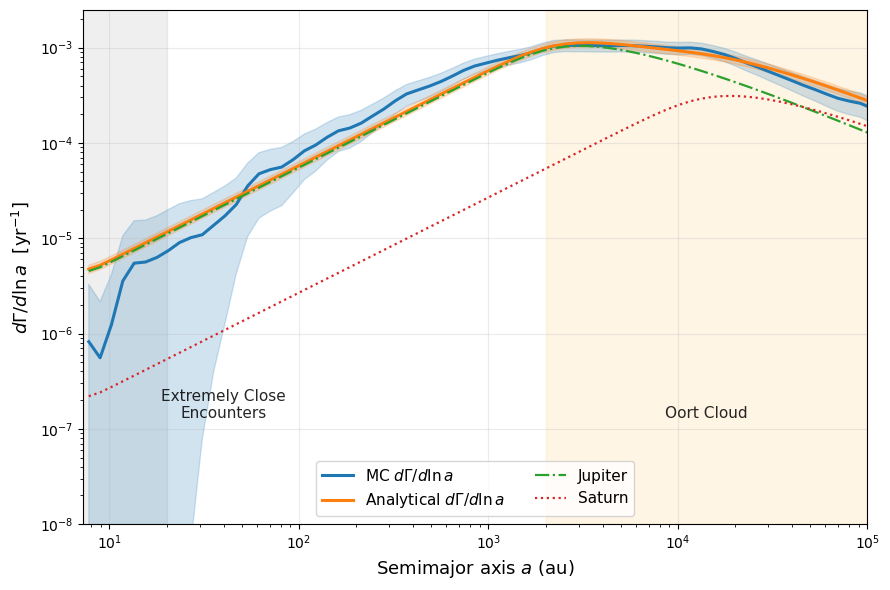

Total Bound Fraction: 15000/380339000
Approx mean time between captures (numeric): 217.67199835817743 years per bound ISO. Upper bound: 2397936.5152212386, Lower bound: 77.12592135285583
Theoretical rate: 220.2171584181745 years per bound ISO.
Finished dynamic-run.


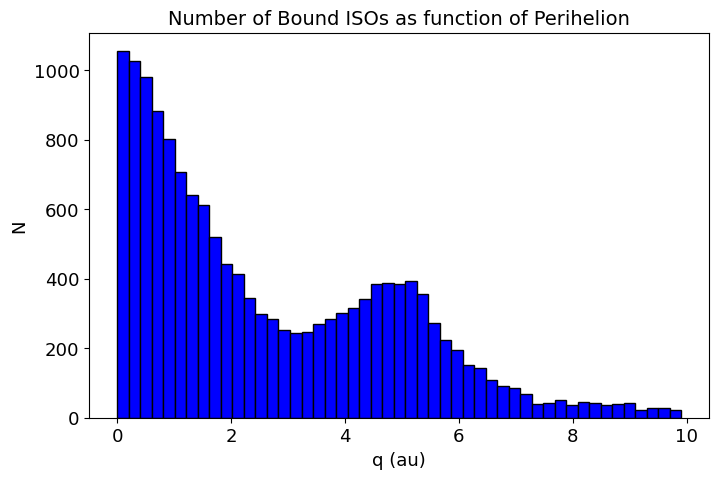

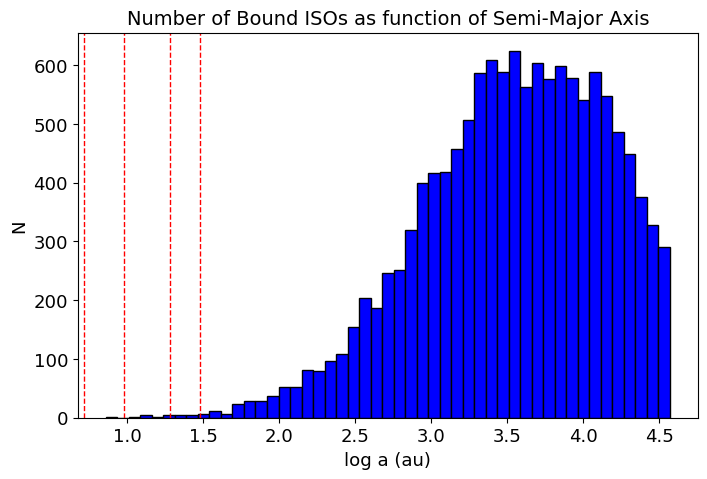

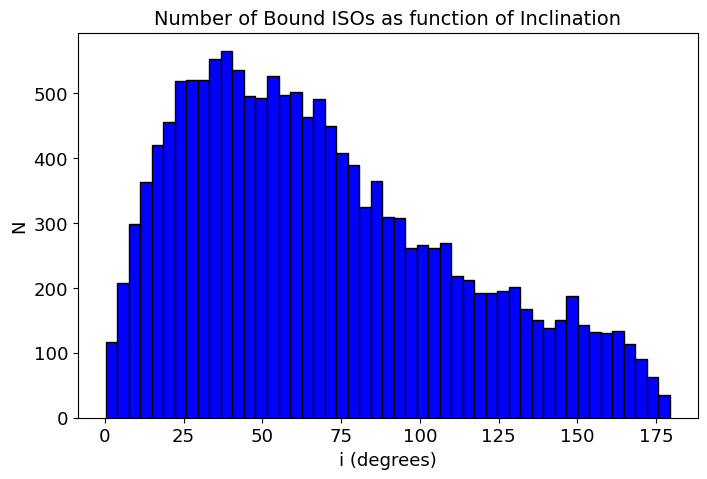

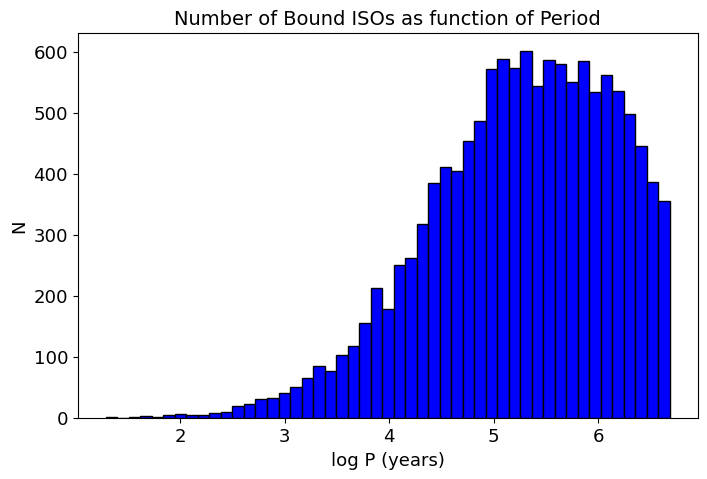

  0%|          | 0/100 [00:00<?, ?it/s]

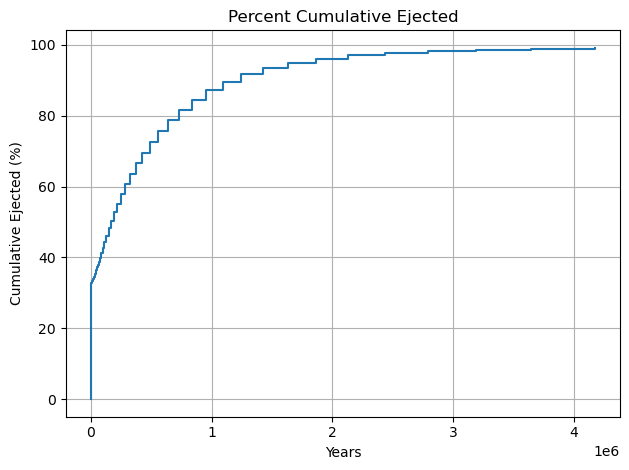

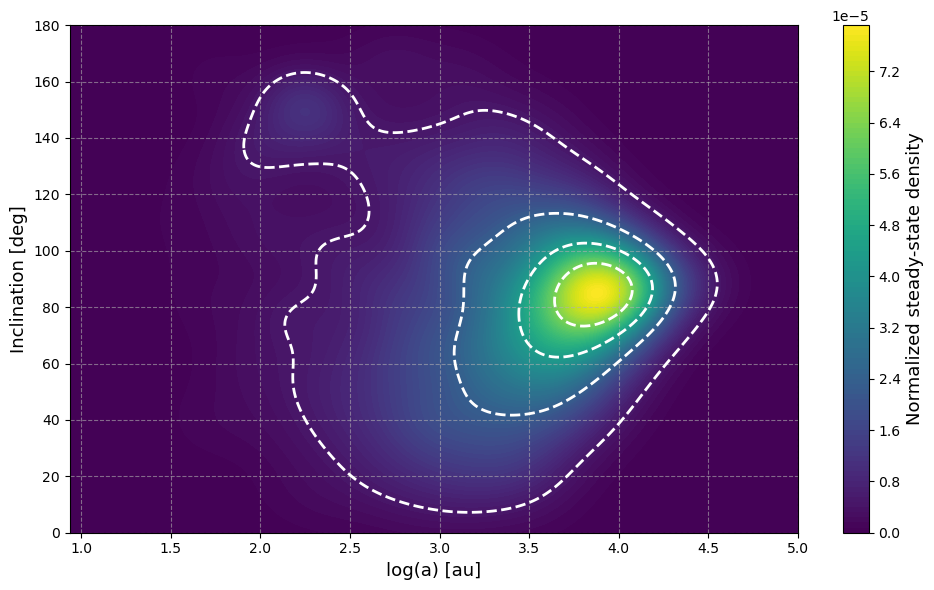

HDR level: 0.9
KDE density threshold: 2.89565e-02
Observed inside HDR: 122 / 1520277
['668643 (2012 DR30)', '709487 (2013 BL76)', '       (2017 MB7)', '       (2020 MQ53)', '     C/1888 P1 (Brooks)', '     C/1890 O2 (Denning)', '     C/1919 Q2 (Metcalf)', '     C/1924 F1 (Reid)', '     C/1949 N1 (Bappu-Bok-Newkirk)', '     C/1952 M1 (Peltier)', '     C/1958 R1 (Burnham-Slaughter)', '     C/1960 B1 (Burnham)', '     C/1966 P1 (Kilston)', '     C/1967 C1 (Seki)', '     C/1969 O1-A (Kohoutek)', '     C/1969 T1 (Tago-Sato-Kosaka)', '     C/1972 X1 (Araya)', '     C/1974 C1 (Bradfield)', '     C/1977 R1 (Kohler)', '     C/1980 Y2 (Panther)', '     C/1981 M1 (Gonzalez)', '     C/1983 J1 (Sugano-Saigusa-Fujikawa)', '     C/1984 V1 (Levy-Rudenko)', '     C/1984 W2 (Hartley)', '     C/1985 R1 (Hartley-Good)', '     C/1986 N1 (Churyumov-Solodovnikov)', '     C/1989 A1 (Yanaka)', '     C/1991 T2 (Shoemaker-Levy)', '     C/1992 U1 (Shoemaker)', '     C/1994 T1 (Machholz)', '     C/1997 BA6 (Spacew

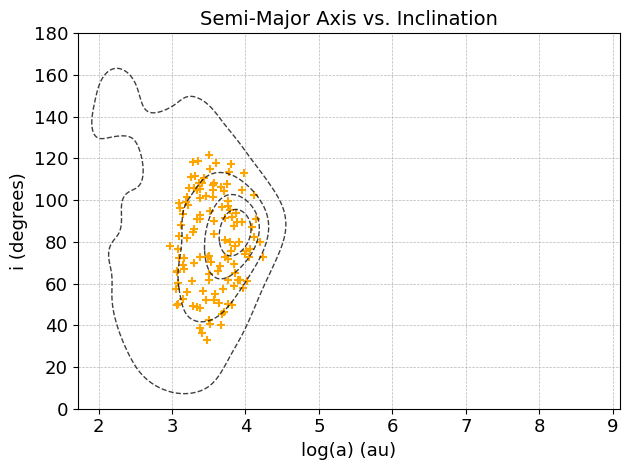

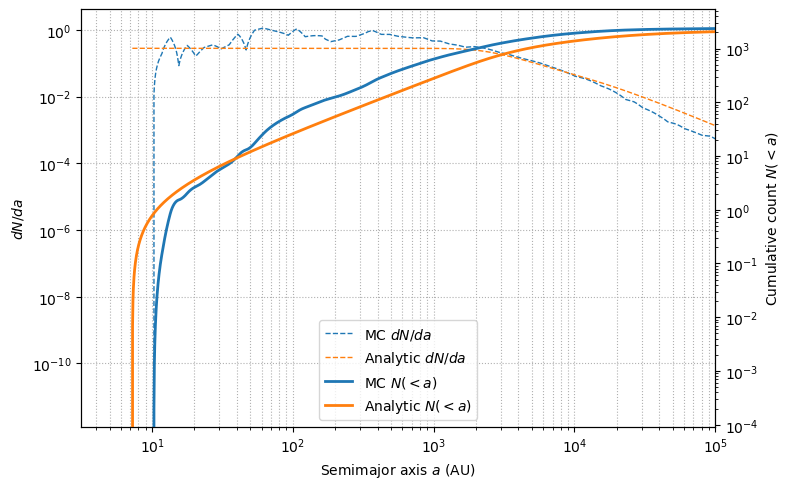

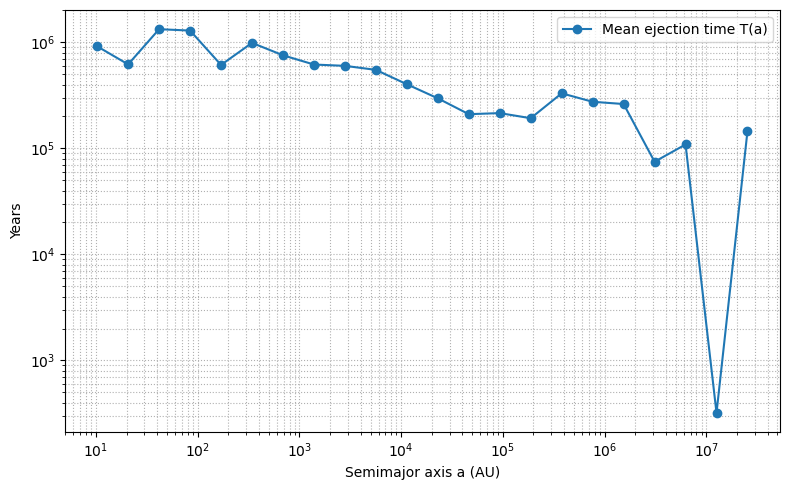

Total Monte-Carlo: 2409.856319385195
Total Analytical: 2227.6152666283547
Percent below 100 AU: 0.02479921751792707


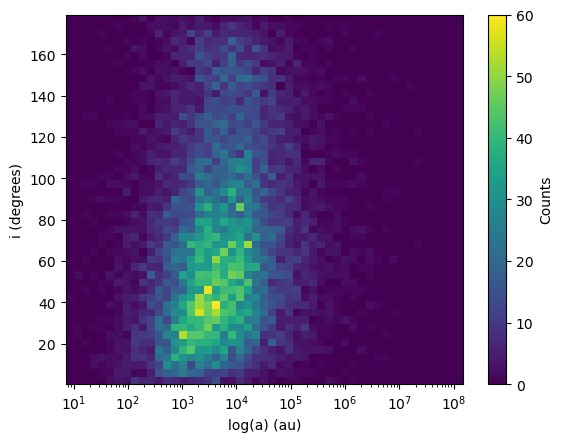

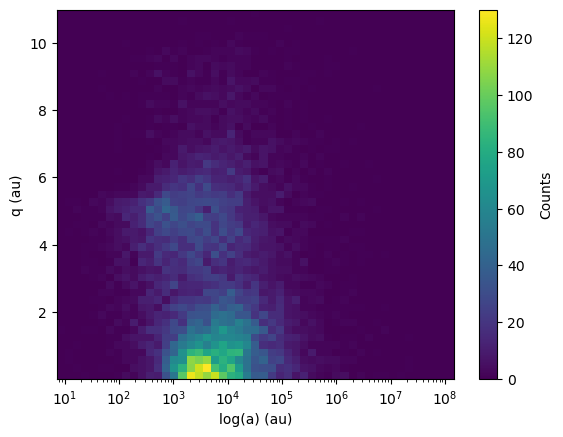

In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)
from dask import config

config.set({
    "distributed.worker.memory.target": 0.99,
    "distributed.worker.memory.spill": 1.00,
    "distributed.worker.memory.pause": 1.00,
    "distributed.worker.memory.terminate": False,
})
import logging

logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)
logging.getLogger("distributed.nanny.memory").setLevel(logging.ERROR)
"""
******************************
JUPITER ISO SINGLE CAPTURES V3
By Rainer Marquardt-Demen
******************************
IMPORTS:
-OS: Retrieve downloads
-REBOUND: REBOUND for N-body integration
-REBOUNDX: reboundX for higher-order effects, such as GR and outgassing
-NUMPY: Math
-MATPLOTLIB: Plotting
-DATETIME: Timestaps
-DASK: Parallel computation
-SCIPY: Integration, special functions, gaussian kernel density estimation, curve fitting
-CSV: csv file loader
-GC: Garbage collection for memory bloating
"""
import os
import rebound as rb
from tqdm.notebook import tqdm
import reboundx as rbx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import font_manager
from datetime import datetime
import dask
from dask.distributed import Client, as_completed, LocalCluster
from collections import deque
from scipy import special
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import scipy.special as special
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import csv
import gc
"""
***********
PARAMETERS:
***********
-N_TARGET: Number of captured ISOs before stopping simulation 
-BATCH_SIZE: Number of particles per batch (~1e4, increase for speed but decrease for less memoy usage)
-MAX_IN_FLIGHT: Maximum number of batches running in parallel
-COL: Flag for collisions
-TMAX: Maximum number of years after initializing RMAX to simulate (>10 years)
-RMAX: Sphere of bombardment, centered on Jupiter. Must be much greater than the Hill radius to converge.
-MAXLIFE: Number of years to run lifetime simulation (OR, if negative, multiplies by capture rate)
-NISO: Number density of ISOs, taken to be 0.1 au^-3
-V_SIGMA: Variance in Maxwell-Boltzmann PDF 
-VMAX: Maximum velocity sampled (<4 km/s or ~0.75 au/yr)
-VMIN: Minimum velocity for calculating maximum impact parameter
-EMAX: Maximum eccentricity sampled. High eccentricities have too high a change in energy to become bound
NOTES:
-UNITS: All units are in au, yr, and Jupiter masses
"""
N_target = 15000
batch_size = int(1e3) 
max_in_flight = 8
col = True
Tmax = int(1e8) 
rmax = 250
maxlife = -int(1e6)
niso = 0.1
v_sigma = 5.510446
vmax = 0.75
emax = 1.3

# bookkeeping / results folder
#timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#results_folder = f"results_{timestamp}"
#os.makedirs(results_folder, exist_ok=True)

# ---------------- Helper functions ----------------
def collisionfunc(sim_pointer, collision):
    """
    Collision resolve function. If collision occurs with the Sun or Jupiter remove ISO. Otherwise nothing occurs
    """
    sim = sim_pointer.contents
    if (sim.particles[collision.p1]==sim.particles["Jupiter"] or sim.particles[collision.p1]==sim.particles["Sun"] or sim.particles[collision.p1]==sim.particles["Saturn"]):
        return 2
    elif (sim.particles[collision.p2]==sim.particles["Jupiter"] or sim.particles[collision.p2]==sim.particles["Sun"] or sim.particles[collision.p2]==sim.particles["Saturn"]):
        return 1
    else:
        return 0

def build_orthonormal_basis(u):
    """
    Given vector u, create an orthonormal basis where u->z axis
    """
    arb = np.array([0.0,0.0,1.0])
    if abs(np.dot(arb, u)) > 0.9:
        arb = np.array([0.0,1.0,0.0])
    e1 = np.cross(u, arb)
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(u, e1)
    e2 /= np.linalg.norm(e2)
    return e1, e2

def instantaneous_velocity_at_r(u_inf, b, phi_b, v_inf, eval_pos, mu):
    """
    Given initial parameters of ISO at infinity (u_inf is the direction of velocity at infinity, b is impact parameter w.r.t. Sun, 
    phi_b is rotation around impact parameter, v_inf is the magnitude of velocity at infinity), the position to evaluate (typically Hill Sphere or Jupiter), 
    and mu=GM_sun, returns velocity direction and position on Hill sphere after hyperbolic (single-body) scattering/deflection with the Sun.
    See checkingisotropy.ipynb for accuracy
    """
    u = np.array(u_inf, dtype=float)
    e1, e2 = build_orthonormal_basis(u)
    e_b = np.cos(phi_b) * e1 + np.sin(phi_b) * e2
    r_perp = b * e_b
    rel_eval = np.array(eval_pos, dtype=float)
    h = b * v_inf
    e = np.sqrt(1.0 + (b**2 * v_inf**4) / (mu**2))
    r_eval = np.linalg.norm(rel_eval)
    p = h**2 / mu
    cos_nu = (p / (r_eval) - 1.0) / e
    if abs(cos_nu) > 1.0:
        return np.zeros(3), None
    sin_nu = -np.sqrt(max(0.0, 1.0 - cos_nu**2))
    nu = np.arctan2(sin_nu, cos_nu)
    cos_nu_inf = -1.0 / e
    sin_nu_inf = np.sqrt(max(0.0, 1.0 - cos_nu_inf**2))
    e_x = -u
    e_y = e_b
    p_hat = cos_nu_inf * e_x + sin_nu_inf * e_y
    theta_p = -sin_nu_inf * e_x + cos_nu_inf * e_y
    r_hat = np.cos(nu) * p_hat + np.sin(nu) * theta_p
    r_vec = (p / (1 + e*np.cos(nu))) * r_hat
    theta_hat = -np.sin(nu) * p_hat + np.cos(nu) * theta_p
    v_r = (mu / h) * e * sin_nu
    v_theta = (mu / h) * (1.0 + e * np.cos(nu))
    v_vec = v_r * r_hat + v_theta * theta_hat
    return v_vec, r_vec

def line_closest_param_and_distance(u_inf, b_vec, C):
    """
    Given line and impact parameter, determine closest distance
    """
    u = u_inf
    s_star = -np.dot(b_vec - C, u)
    closest = b_vec + s_star * u
    dmin = np.linalg.norm(closest - C)
    return s_star, dmin, closest


def F(v, v_sigma=v_sigma):
    return special.erf(v/(np.sqrt(2)*v_sigma)) - np.sqrt(2/np.pi)*(v/v_sigma)*np.exp(-v**2/(2*v_sigma**2))

def f(v, v_sigma=v_sigma):
    """
    Probability distribution function for 3D Maxwell
    """
    return np.sqrt(2/np.pi) * (v**2/v_sigma**3) * np.exp(-v**2/(2*v_sigma**2))

"""
********************
Template Simulation:
********************
Jupiter, Sun, and Saturn. All ISOs are considered test particles; values are taken as mean orbital elements for Jupiter and Saturn
"""
template_sim = rb.Simulation()
template_sim.units = ('yr', 'au', 'mjupiter')
template_sim.add("Sun", hash="Sun")
Msun = template_sim.particles[0].m
template_sim.particles[0].r=0.00465047
template_sim.add(
    m = 1.0,                      # Jupiter mass in MJ
    a = 5.2044,                   # au
    e = 0.0489,
    inc = np.deg2rad(1.303),
    Omega = np.deg2rad(100.464),
    omega = np.deg2rad(273.867),
    M = np.deg2rad(20.020),
    r = 4.7789e-4,
    hash = "Jupiter"
)
MJup = template_sim.particles[1].m
aJup = template_sim.particles[1].a
rJ = np.array([template_sim.particles["Jupiter"].x, template_sim.particles["Jupiter"].y, template_sim.particles["Jupiter"].z])
vJ = np.array([template_sim.particles["Jupiter"].vx, template_sim.particles["Jupiter"].vy, template_sim.particles["Jupiter"].vz])
template_sim.add(
    m = 0.299409946,        # Saturn mass in Jupiter masses
    a = 9.5826,          # au
    e = 0.0565,
    inc = np.deg2rad(2.485),
    Omega = np.deg2rad(113.665),
    omega = np.deg2rad(339.392),
    M = np.deg2rad(317.020),
    r = 3.8926e-4,
    hash="Saturn"
)
aSat = template_sim.particles[2].a
MSat = template_sim.particles[2].m
template_sim.N_active=3
G = template_sim.G

print(
    f"RUN PARAMS | N_target={N_target}, batch_size={batch_size}, max_in_flight={max_in_flight}\n "
    f"Max Capture Time={Tmax} yr, Sphere={rmax:.3f} au, Lifetime Time={maxlife} times mean capture time\n"
    f"Number density of ISOs={niso:.3e} au^-3\n"
    f"Velocity Parameters: Sigma={v_sigma:.3f} au/yr, V max={vmax:.3f} au/yr\n"
    f"Collisions={col}\n"
    f"Sun: Mass={Msun:.3e} M_J, Radius={4.65e-3} au\n"
    f"Jupiter: Mass={MJup:.3e} M_J, Semimajor axis={aJup:.3e} au, Position={rJ}, Velocity={vJ}, Radius={4.78e-4}\n"
    f"G={G:.3e} au^3 M_J^-1 yr^-1"
)

def simulate_batch(batch_size=batch_size, template_sim=template_sim, Tmax=Tmax, rmax=rmax, v_sigma=v_sigma, vmax=vmax, col=col, collisionfunc=collisionfunc, 
                   vJ=vJ, rJ=rJ, G=G, aJup=aJup, Msun=Msun, e_max=emax):
    # 1. Draw velocities using inverse CDF
    rng = np.random.default_rng() 
    u = rng.random(batch_size) * F(vmax)
    v = u*v_sigma*2
    for _ in range(5): 
        Ftest = F(v, v_sigma) 
        ftest = np.sqrt(2/np.pi)*(v**2/v_sigma**3)*np.exp(-v*v/(2*v_sigma*v_sigma)) 
        v -= (Ftest - u) / ftest 
        v = np.clip(v, 0, vmax)
    # =========================== # 2. Draw directions (vectorized) # =========================== 
    cos_ti = 2*rng.random(batch_size) - 1 
    phi = 2*np.pi*rng.random(batch_size) 
    sin_t = np.sqrt(1 - cos_ti**2) 
    u_dir = np.stack([sin_t * np.cos(phi), sin_t * np.sin(phi), cos_ti], axis=1) 
    #=========================== # 3. Impact parameter draw # =========================== 
    vmin = min(v)
    bmax = (aJup + rmax) * np.sqrt(1 + 2*G*Msun / ((aJup + rmax) * (vmin**2)))
    b = bmax * np.sqrt(rng.random(batch_size))
    phi_b = 2*np.pi*rng.random(batch_size)
    # Build orthonormal basis for each u_dir
    e1 = np.zeros_like(u_dir)
    e2 = np.zeros_like(u_dir)

    tmp = np.copy(u_dir)
    mask_z = np.abs(tmp[:,2]) < 0.9
    tmp[mask_z] = np.array([0,0,1])
    tmp[~mask_z] = np.array([1,0,0])

    e1 = np.cross(u_dir, tmp)
    e1 /= np.linalg.norm(e1, axis=1)[:,None]
    e2 = np.cross(u_dir, e1)

    # b-plane direction
    e_b = (
        np.cos(phi_b)[:,None] * e1 +
        np.sin(phi_b)[:,None] * e2
    )

    r_perp = b[:,None] * e_b

    # ===========================
    # 4. Jupiter-sphere intersection test
    # ===========================
    dvec = r_perp - rJ
    B = 2*np.sum(u_dir * dvec, axis=1)
    Cc = np.sum(dvec*dvec, axis=1) - rmax**2
    disc = B*B - 4*Cc

    hits = disc >= 0
    if not np.any(hits):
        # Nothing enters Jupiter's sphere
        return [], v, bmax

    # Keep only survivors
    u_dir_h = u_dir[hits]
    b_h     = b[hits]
    phi_b_h = phi_b[hits]
    v_h     = v[hits]
    B_h     = B[hits]
    Cc_h    = Cc[hits]
    r_perp_h = r_perp[hits]
    
    disc_h = disc[hits]
    sqrt_disc = np.sqrt(disc_h)

    s1 = (-B_h - sqrt_disc)/2
    s2 = (-B_h + sqrt_disc)/2
    s = np.where(s1 > 0, s1, s2)
    s = np.where(s <= 0, s2, s1)  # fallback

    eval_pts = r_perp_h + s[:,None] * u_dir_h
    
    N = len(eval_pts)
    vel_vecs = np.zeros((N,3))
    pos_vecs = np.zeros((N,3))
    ok = np.ones(N, dtype=bool)

    mu = G * Msun
    # Find velocity/position on sphere, prune any failures
    for i in range(N):
        vel, pos = instantaneous_velocity_at_r(
            u_dir_h[i], b_h[i], phi_b_h[i],
            v_h[i], eval_pts[i],
         mu
        )

        if pos is None:
            ok[i] = False
            continue

        # --- solar two-body eccentricity ---
        r = np.linalg.norm(pos)
        v2 = np.dot(vel, vel)
        E = 0.5*v2 - mu/r
        h = np.linalg.norm(np.cross(pos, vel))

        e = np.sqrt(1.0 + 2.0*E*h*h/(mu*mu))

        # --- prune strongly hyperbolic trajectories ---
        if e > e_max:
            ok[i] = False
            continue

        vel_vecs[i] = vel
        pos_vecs[i] = pos

    # --------------------
    # Apply pruning
    # --------------------
    v_h = v_h[ok]
    u_dir_h   = u_dir_h[ok]
    b_h       = b_h[ok]
    phi_b_h   = phi_b_h[ok]
    vel_vecs  = vel_vecs[ok]
    pos_vecs  = pos_vecs[ok]
    N = len(vel_vecs)

    if N == 0:
        return [], v, bmax

    # ===========================
    # 7. Run ONE REBOUND simulation for all inward-crossers
    # ===========================
    results = []

    # Create one sim with many test particles
    sim = template_sim.copy()
    if col:
        sim.collision = "direct"
        sim.collision_resolve = collisionfunc

    particle_hashes = []

    for pos_vec, vel_vec in zip(pos_vecs, vel_vecs):
        h = str(sim.N)  # unique small int; or use uuid if you prefer
        p = sim.add(
            hash=h,
            x=pos_vec[0], y=pos_vec[1], z=pos_vec[2],
            vx=vel_vec[0], vy=vel_vec[1], vz=vel_vec[2],
        )
        particle_hashes.append(h)
    
    for i in range(Tmax):
        if sim.N==3:
            break
        sim.integrate(10*i)
        for (pos_vec, vel_vec, vi), h in zip(zip(pos_vecs, vel_vecs, v), particle_hashes):
            # Try accessing particle by hash
            try:
                p = sim.particles[h]
                orb = p.orbit(sim.particles[0])
                if orb.e < 1.0:
                    results.append({
                        "x": pos_vec[0], "y": pos_vec[1], "z": pos_vec[2],
                        "vx": vel_vec[0], "vy": vel_vec[1], "vz": vel_vec[2],
                        "ai": orb.a, "ei": orb.e, "ii": orb.inc, "Pi": orb.P,
                        "v_flux": vi, "Tcap": 10*i
                    })
                    sim.remove(hash=h)
                elif p**sim.particles[0]>rmax+10.4:
                    sim.remove(hash=h)
            except rb.ParticleNotFound:
                # particle was removed (collision/ejection)
                pass
    del sim
    return results, v, bmax

# ---------------- Setup Dask ----------------
try:
    client.close()
    cluster.close()
except:
    pass
cluster = LocalCluster(
    dashboard_address=":8787",
    n_workers = max(4, os.cpu_count() - 2),
    threads_per_worker=1,
    memory_limit='4GB'
)
client = Client(cluster)
print(f"Dask dashboard: http://localhost:8787/")

# ---------------- Parameters ----------------
captured = 0
attempted = 0
Nv=[]
bmax = 0
Tcap = []
x_bound, y_bound, z_bound = [], [], []
vx_bound, vy_bound, vz_bound = [], [], []
ainitial, einitial, iinitial, Pinitial, vflux= [], [], [], [], []

# ---------------- Progress bars (both tqdm) ----------------
pbar_captured = tqdm(total=N_target, desc="Captured ISOs", dynamic_ncols=True)
pbar_attempted = tqdm(total=None, desc="Attempted ISOs", dynamic_ncols=True)

# ---------------- Submit initial batches ----------------
active_futures = deque()
initial_batches = min(max_in_flight, (N_target // batch_size) + 1)

for _ in range(initial_batches):
    fut = client.submit(simulate_batch, batch_size, pure=False)
    active_futures.append(fut)

ac = as_completed(list(active_futures))

try:
    while captured < N_target:
        finished_future = next(ac)
        batch, nv, bmaxi = finished_future.result()
        Nv.extend(nv) 
        if bmaxi>bmax:
            bmax=bmaxi
        captured_batch = len(batch)
        attempted+=batch_size
        pbar_attempted.update(batch_size)
        pbar_captured.update(captured_batch)
        # Update captured ISOs
        for particle in batch:
            # store bound particle data
            captured+=1
            x_bound.append(particle["x"])
            y_bound.append(particle["y"])
            z_bound.append(particle["z"])
            vx_bound.append(particle["vx"])
            vy_bound.append(particle["vy"])
            vz_bound.append(particle["vz"])
            ainitial.append(particle["ai"])
            einitial.append(particle["ei"])
            iinitial.append(particle["ii"])
            Pinitial.append(particle["Pi"])
            vflux.append(particle["v_flux"]) 
            Tcap.append(particle["Tcap"])
        if captured >= N_target:
            break

        # Submit new batch to maintain max_in_flight
        if captured < N_target:
            new_future = client.submit(simulate_batch, batch_size, pure=False)
            ac.add(new_future)
            active_futures.append(new_future)

finally:
    for fut in active_futures:
        try:
            client.cancel(fut)
        except:
            pass

    pbar_captured.close()
    pbar_attempted.close()

# ---------------- Post-processing and rate calculation ----------------
nobound = captured
if nobound == 0:
    print(f"No bound objects found after {attempted} interstellar object attempts.")
else:
    # Convert to arrays
    v_captured = np.array(vflux)   # captured velocities
    v_attempted = np.array(Nv)     # all attempted velocities

    nbinsv = int(2*nobound*(1/3))
    nvmin, nvmax = v_attempted.min(), v_attempted.max()
    binsv = np.linspace(nvmin, nvmax, nbinsv+1)
    bin_centersv = 0.5*(binsv[:-1] + binsv[1:])
    bin_widthsv = np.diff(binsv)

    # Digitize
    indices_captured = np.digitize(v_captured, binsv) - 1
    indices_attempted = np.digitize(v_attempted, binsv) - 1

    # Initialize sigma_v
    sigma_v = np.zeros(nbinsv)
    sigma_v_plus = np.zeros(nbinsv)
    sigma_v_minus = np.zeros(nbinsv)

    for i in range(nbinsv):
        Ncaptured = np.sum(indices_captured == i)
        Nentered = np.sum(indices_attempted == i)

        p = Ncaptured / Nentered
        sigma_p = np.sqrt(p*(1-p)/Nentered)

        A = niso * np.pi * bmax**2

        if Nentered > 0:
            sigma_v[i] = A * p
            sigma_v_plus[i] = A * (p + 3*sigma_p)
            sigma_v_minus[i] = A * max(0, p - 3*sigma_p)
        else:
            sigma_v[i] = 0.0
            sigma_v_plus[i] = 0.0
            sigma_v_minus[i] = 0.0

    # Integrate v * f(v) * sigma(v)
    caprate = np.trapezoid(bin_centersv * f(bin_centersv) * sigma_v, bin_centersv)
    caprate_plus = np.trapezoid(bin_centersv * f(bin_centersv) * sigma_v_plus, bin_centersv)
    caprate_minus = np.trapezoid(bin_centersv * f(bin_centersv) * sigma_v_minus, bin_centersv)

    def func(X, X0=2.95, alp=0.82): #numerical fit in Dehnen and Hands
        return (8/(3*X0**2)) * (np.arcsinh((X0/X)**(2/alp)))**alp
    ainitial = np.array(ainitial)   

    nbinsa = int(np.sqrt(nobound))

    amin = np.min(ainitial[ainitial > 0])
    amax = ainitial.max()

    binsa = np.logspace(np.log10(amin), np.log10(amax), nbinsa + 1)

    abin_centers = 0.5 * (binsa[:-1] + binsa[1:])
    abin_widths = np.diff(binsa)
    dlna = np.diff(np.log(binsa))

    vbin_index = np.digitize(v_captured, binsv) - 1
    vbin_index = np.clip(vbin_index, 0, nbinsv - 1)

    weights = np.zeros_like(v_captured)
    p_capture = np.zeros_like(v_captured)


    for i in range(nbinsv):
        mask = vbin_index == i
        Nentered = np.sum(indices_attempted == i)
        Ncaptured = np.sum(indices_captured == i)
    
        if Nentered > 0:
            p = Ncaptured / Nentered

            weights[mask] = (
                niso*v_captured[mask]
                * bin_widthsv[i]
                * f(v_captured[mask])
                * np.pi * bmax**2
                / Nentered
            )

            p_capture[mask] = p

    # --- Final differential rate and uncertainty ---
    dQ_da = np.zeros(nbinsa)
    dQ_dlna = np.zeros(nbinsa)
    dQ_dlna_u = np.zeros(nbinsa)
    dQ_dlna_d = np.zeros(nbinsa)
    abin_index = np.digitize(ainitial, binsa) - 1
    abin_index = np.clip(abin_index, 0, nbinsa - 1)
    for j in range(nbinsa):
        mask = abin_index == j

        # weights and capture probabilities of captured objects in this bin
        w = weights[mask]
        p = p_capture[mask]

        # weighted sum (rate contribution)
        W = np.sum(w)
    
        variance = np.sum(w**2)


        sigma = np.sqrt(variance)

        # dQ/d ln a
        if dlna[j] > 0:
            dQ_dlna[j] = W / dlna[j]
            dQ_dlna_u[j] = (W + 3*sigma) / dlna[j]
            dQ_dlna_d[j] = max(0.0, W - 3*sigma) / dlna[j]

        # dQ/da
        if abin_widths[j] > 0:
            dQ_da[j] = W / abin_widths[j]


    P0 = 1/(4*np.pi) * np.sqrt(2/np.pi) * 1/v_sigma**3
    def adQdlnaJ(a, t, G=G, Msun=Msun, MJup=MJup, aJup=aJup, P0=P0):
        A= niso*P0 * 2 * np.pi**2 * (G*(Msun+MJup))**2 * (aJup/a) * func((aJup*Msun)/(MJup*a))
        if t==0:
            return A #see Dehnen and Hands
        if t==1:
            return A+0.1*A
        if t==2:
            return A-0.1*A

    def adQdlnaS(a, t, G=G, Msun=Msun, MSat=MSat, aSat=aSat, P0=P0):
        A= niso*P0 * 2 * np.pi**2 * (G*(Msun+MSat))**2 * (aSat/a) * func((aSat*Msun)/(MSat*a))
        if t==0:
            return A #see Dehnen and Hands
        if t==1:
            return A+0.1*A
        if t==2:
            return A-0.1*A
    
    Q_cumulative = np.cumsum(dQ_da * abin_widths)
    analytical = adQdlnaJ(abin_centers, 0) + adQdlnaS(abin_centers, 0)
    analyticald = adQdlnaJ(abin_centers, 2) + adQdlnaS(abin_centers, 2)
    analyticalu = adQdlnaJ(abin_centers, 1) + adQdlnaS(abin_centers, 1)
    Q_analytical_cumulative = np.cumsum(analytical * dlna)
    caprate_theory = Q_analytical_cumulative[-1]

    smoothQa = gaussian_filter1d(dQ_dlna, sigma=1)
    smoothQd = gaussian_filter1d(dQ_dlna_d, sigma=1)
    smoothQu = gaussian_filter1d(dQ_dlna_u, sigma=1)
    smoothA = gaussian_filter1d(analytical, sigma=1)
    smoothAu = gaussian_filter1d(analyticalu, sigma=1)
    smoothAd = gaussian_filter1d(analyticald, sigma=1)
    smoothJ = gaussian_filter1d(adQdlnaJ(abin_centers,0), sigma=1)
    smoothS = gaussian_filter1d(adQdlnaS(abin_centers,0), sigma=1)

    fig, ax1 = plt.subplots(figsize=(9, 6))
    oort_inner = 2e3
    oort_outer = 1e5

    # ---------------- Regions ----------------
    ax1.axvspan(amin, 20,
            color="gray", alpha=0.12, zorder=0)

    ax1.axvspan(oort_inner, oort_outer,
            color="orange", alpha=0.10, zorder=0)

    # ---------------- Main Curves ----------------
    ax1.loglog(abin_centers, smoothQa,
           lw=2.2, color="C0",
           label=r"MC $d\Gamma/d\ln a$")

    ax1.fill_between(abin_centers, smoothQd, smoothQu,
                 color="C0", alpha=0.20)

    ax1.loglog(abin_centers, smoothA,
            lw=2.2, color="C1",
           label=r"Analytical $d\Gamma/d\ln a$")

    ax1.fill_between(abin_centers, smoothAd, smoothAu,
                 color="C1", alpha=0.20)

    ax1.loglog(abin_centers, smoothJ,
           lw=1.6, ls="-.", color="C2",
           label=r"Jupiter")

    ax1.loglog(abin_centers, smoothS,
           lw=1.6, ls=":", color="C3",
           label=r"Saturn")

    # ---------------- Formatting ----------------
    ax1.set_xlabel("Semimajor axis $a$ (au)", fontsize=13)
    ax1.set_ylabel(r"$d\Gamma/d\ln a$  [yr$^{-1}$]", fontsize=13)

    # safer log-scale y limits
    ymax = np.nanmax([smoothQu.max(), smoothAu.max()])
    ax1.set_ylim(1e-8, ymax * 2)
    ax1.set_xlim(amin, 1e5)

    # Subtle grid (major only looks cleaner in log plots)
    ax1.grid(True, which="major", alpha=0.25)

    # ---------------- Region Labels ----------------
    y_text = ax1.get_ylim()[0] * 12

    ax1.text(40, y_text,
         "Extremely Close\nEncounters",
         ha="center", va="bottom",
         fontsize=11, alpha=0.85)

    x_oort = np.sqrt(oort_inner * oort_outer)
    ax1.text(x_oort, y_text,
         "Oort Cloud",
         ha="center", va="bottom",
         fontsize=11, alpha=0.85)
    # ---------------- Legend ----------------
    leg = ax1.legend(loc="lower center",
                 frameon=True,
                 fontsize=11,
                 ncol=2)

    plt.tight_layout()
    plt.show()

    captime = 1/caprate
    print(f"Total Bound Fraction: {nobound}/{attempted}")
    print(f"Approx mean time between captures (numeric): {captime} years per bound ISO. Upper bound: {1/caprate_minus}, Lower bound: {1/caprate_plus}")
    print(f"Theoretical rate: {1/caprate_theory} years per bound ISO.")

# Save results for later analysis
#np.savez_compressed(f"{results_folder}/captures_summary.npz",
                    #x_bound=x_bound, y_bound=y_bound, z_bound=z_bound,
                    #vx_bound=vx_bound, vy_bound=vy_bound, vz_bound=vz_bound,
                    #ainitial=ainitial, einitial=einitial, vflux=vflux,
                    #attempted=attempted, captured=captured)

print("Finished dynamic-run.")
def orbital_prop_plot(values, I, taper, log):
    num_bins = int(2*len(values)**(1/3))
    if I=="Semi-Major Axis":
        xlabel = "log a (au)"
    elif I =="Perihelion":
        xlabel = 'q (au)'
    elif I=="Inclination":
        xlabel = 'i (degrees)'
    elif I=="Eccentricity":
        xlabel='e'
    elif I=="Period":
        xlabel='log P (years)'
    if log:     
        if taper:
            Q1 = np.percentile(values, 25)
            Q3 = np.percentile(values, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            values = [x for x in values if x <= upper_bound]
            values = [np.log10(x) for x in values]
        bins = np.linspace(min(values), max(values), num_bins + 1) 
        counts, bin_edges = np.histogram(values, bins=bins)
        plt.figure(figsize=(8, 5))
        plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), edgecolor='black',color='blue', align='edge', alpha = 1)
        plt.xlabel(f'{xlabel}', fontsize=13)
        plt.ylabel('N', fontsize=13)
        plt.xticks(fontsize=13)
        plt.yticks(fontsize=13)
        plt.title(f'Number of Bound ISOs as function of {I}', fontsize=14)
        ax = plt.gca()
        if I=="Semi-Major Axis":
            ax.axvline(x=np.log10(5.2), color='red', linestyle='--', linewidth=1)
            ax.axvline(x=np.log10(9.5), color='red', linestyle='--', linewidth=1)
            ax.axvline(x=np.log10(19.19), color='red', linestyle='--', linewidth=1)
            ax.axvline(x=np.log10(30.1), color='red', linestyle='--', linewidth=1)
        plt.show()
    else:     
        if taper:
            Q1 = np.percentile(values, 25)
            Q3 = np.percentile(values, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            values = [x for x in values if lower_bound <= x <= upper_bound]
        bins = np.linspace(min(values), max(values), num_bins + 1)
        counts, bin_edges = np.histogram(values, bins=bins)
        plt.figure(figsize=(8, 5))
        plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), edgecolor='black',color='blue', align='edge', alpha = 1)
        plt.xlabel(f'{xlabel}', fontsize=13)
        plt.xticks(fontsize=13)
        plt.yticks(fontsize=13)
        plt.ylabel('N', fontsize=13)
        plt.title(f'Number of Bound ISOs as function of {I}', fontsize=14)
        plt.show()

ainitial = np.asarray(ainitial, dtype=np.float64)
einitial= np.asarray(einitial, dtype=np.float64)
iinitial = np.asarray(iinitial, dtype=np.float64)
qinitial = ainitial*(1-einitial) 
countsei = orbital_prop_plot(qinitial, "Perihelion", True, False)
countsai = orbital_prop_plot(ainitial, "Semi-Major Axis", True, True)
iinitial[:] = [x * (180/np.pi) for x in iinitial]
countsii = orbital_prop_plot(iinitial, "Inclination", False, False)
countsPi = orbital_prop_plot(Pinitial, "Period", True, True)
"""
***********************
Lifetime and Stability:
***********************
We initialize our simulations and include additional effects and integrate for long periods of time to check for ejection
"""
if maxlife<0:
    maxlife=(maxlife*(-1)*captime) #see note on maxlife at configuration

def life_simulate(xi, yi, zi, vxi, vyi, vzi, T, maxlife=maxlife, template_sim=template_sim,
                  captime=captime, col=col, collisionfunc=collisionfunc):
    life = template_sim.copy()
    if col:
        life.collision = "direct"
        life.collision_resolve = collisionfunc
    
    life.add(x=xi,y=yi,z=zi,vx=vxi,vy=vyi,vz=vzi)
          
    """
    After integrating again (the conditions should be similar enough), we continue until the particle is ejected or 
    maximum lifetime is reached
    Case 1: Particle collides into the Sun or Jupiter
    Case 2: Maximum lifetime reached, we save the orbital parameters
    Case 3: Becomes unbound (e>=1)
    """
    life.integrate(T)
    times = []
    a_samples = []
    e_samples = []
    inc_samples = []
    r_samples = []

    # useful
    def record():
        orb = life.particles[3].orbit(primary=life.particles["Sun"])
        times.append(life.t)
        a_samples.append(orb.a)
        e_samples.append(orb.e)
        inc_samples.append(orb.inc)

    avglife = None
    if life.N == 3:
        return {
            "times": None
        }
    elif life.particles[3].orbit(primary=life.particles["Sun"]).e>=1:
        return {
            "times": None
        }
    else: 
        record()
        # -------------------------------------------------------
        #   Main life loop
        # -------------------------------------------------------
        for j in range(int(maxlife+T)):
            life.integrate(life.t + 100)

            # event: lost (particle removed => N==3)
            if life.N == 3:
                avglife = (j*100+T)
                break
            # event: hyperbolic
            orb_now = life.particles[3].orbit(primary=life.particles["Sun"])
            if orb_now.e >= 1:
                avglife = (j*100+T)
                break

            # event: end of maxlife
            if j == int((maxlife+T-1)/100):
                avglife = (j*100+T)
                break
            record()
        
    del life

    # ------------------
    # compute weights dt for detectability
    # ------------------
    times = np.array(times)
    a_samples = np.array(a_samples)
    e_samples = np.array(e_samples)
    inc_samples = np.array(inc_samples)

    # Return full history + bound-state snapshot
    return {
        "avglife": avglife,
        "times": times,
        "a_samples": a_samples,
        "e_samples": e_samples,
        "inc_samples": inc_samples
    }

"""
********************
Parallel Processing:
********************
Partition into batches and submit to dask as a futures.
"""
def simulate_life_batch(batch_array):
    return [life_simulate(*map(float, row)) for row in batch_array]

all_particles_args = np.array(list(zip(
    x_bound, y_bound, z_bound, vx_bound, vy_bound, vz_bound, Tcap
)))

batch_size = int(nobound / 100)
batches = [all_particles_args[i:i+batch_size]
           for i in range(0, len(all_particles_args), batch_size)]

ac = as_completed()
futures = []

# launch
for batch in batches:
    future = client.submit(simulate_life_batch, batch)
    ac.add(future)
    futures.append(future)

# gather
all_results = []
for f in tqdm(ac, total=len(futures)):
    all_results.extend(f.result())

a_bound = []
q_bound = []
inc_bound = []
e_bound = []
ejected = []

for p in all_results:

    if p["times"] is None:  # safety
        continue
    
    # compute weighted mean for this particle
    a_w = p["a_samples"]
    e_w = p["e_samples"]
    inc_w = p["inc_samples"]
    valid = np.isfinite(a_w)
    if valid.sum() == 0:
        continue  # nothing usable
    ejected.append(p["avglife"])
    a_vals = a_w[valid]
    e_vals = e_w[valid]
    inc_vals = inc_w[valid]
    inc_vals[:] = [x * (180/np.pi) for x in inc_vals]
    a_vals = np.asarray(a_vals, dtype=np.float64)
    e_vals = np.asarray(e_vals, dtype=np.float64)
    q_vals = a_vals*(1-e_vals) 
    a_bound.append(a_vals)
    q_bound.append(q_vals)
    inc_bound.append(inc_vals)
    e_bound.append(e_vals)

"""
*********
Plotting:
*********
"""
#solar system objects satisfying rough inclination bounds (10<i<160), q<10 au, 100<a<10^5
csv_file_path = '/Users/rainermarquardt-demen/Downloads/finalobj.csv' 
data_dict_list = []

with open(csv_file_path, 'r', newline='') as file:
    csv_reader = csv.DictReader(file)
    for row in csv_reader:
        data_dict_list.append(row)

alla=[]
alle=[]
allname=[]
allinc =[]

for i in range(len(data_dict_list)):
    alla.append(data_dict_list[i]["a"])
    allname.append(data_dict_list[i]["full_name"])
    alle.append(data_dict_list[i]["e"])
    allinc.append(data_dict_list[i]["i"])

alle = np.asarray(alle, dtype=np.float64)
alla = np.asarray(alla, dtype=np.float64)
allinc = np.asarray(allinc, dtype=np.float64)

sim_i = np.array([np.mean(i) for i in inc_bound])
sim_a = np.array([np.mean(a) for a in a_bound])
sim_e = np.array([np.mean(e) for e in e_bound])
weights = np.array(ejected)

def ecc_a_inc(canda, candi, loga_grid, i_grid, kde_masked, thresholds):
    upper_bound = 10000000
    newcanda = []
    newcandi = []

    for i in range(len(canda)):
        if canda[i] < upper_bound:
            newcanda.append(np.log10(canda[i]))
            newcandi.append(candi[i])

    bold_font = font_manager.FontProperties(weight='bold')
    all_x = []

    for thresh in thresholds:
        cs = plt.contour(
            loga_grid, i_grid, kde_masked,
            levels=[thresh],
            colors='black',
            linestyles='dashed',
            linewidths=1,
            alpha=0.75,
            zorder=4
        )

        # Safely collect x coordinates from contour segments
        if cs.allsegs and cs.allsegs[0]:
            for seg in cs.allsegs[0]:
                all_x.extend(seg[:, 0])

    scatter2 = plt.scatter(newcanda, newcandi,
                           color='orange', marker='+',
                           alpha=1, zorder=2)

    plt.title('Semi-Major Axis vs. Inclination', fontsize=14)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    if all_x:
        plt.xlim(min(all_x)*0.9, max(all_x)*2)

    plt.xlabel('log(a) (au)', fontsize=13)
    plt.ylim(0, 180)
    plt.ylabel('i (degrees)', fontsize=13)

    plt.grid(True, which='both', linestyle='--',
             linewidth=0.5, alpha=0.9)

    plt.tight_layout()
    plt.show()


# ======================================================
# Steady-state N(a,i) = T(a,i) * Gamma(a,i)
# ======================================================

def heatmap_ai_steadystate(a_bound, inc_bound, lifetimes,
                           obs_a=None, obs_i=None,
                           levels=[0.9, 0.5, 0.25, 0.1],
                           gridsize=500):
    """
    KDE heatmap of steady-state ISO population N(a,i),
    weighting each orbit by its mean bound lifetime.

    Parameters
    ----------
    a_bound : list of arrays
        Semi-major axis samples for each particle
    inc_bound : list of arrays
        Inclination samples (deg) for each particle
    lifetimes : array-like
        Mean bound lifetime per particle
    obs_a, obs_i : arrays, optional
        Observed object orbital elements to overlay
    levels : list
        HDR cumulative probability levels
    gridsize : int
        KDE grid resolution
    """

    # -------- Flatten + weight --------
    a_ss = a_bound
    i_ss = inc_bound
    weights = lifetimes

    loga = np.log10(a_ss)

    # -------- KDE --------
    values = np.vstack([loga, i_ss])
    kde = gaussian_kde(values, weights=weights)

    # -------- Evaluation grid --------
    loga_min, loga_max = loga.min(), loga.max()
    i_min, i_max = 0, 180

    loga_grid, i_grid = np.mgrid[
        loga_min:loga_max:gridsize*1j,
        i_min:i_max:gridsize*1j
    ]

    positions = np.vstack([loga_grid.ravel(), i_grid.ravel()])
    density = kde(positions).reshape(loga_grid.shape)

    # Normalize for HDR calculation
    density /= density.sum()

    # -------- HDR thresholds --------
    flat = density.ravel()
    idx = np.argsort(flat)[::-1]
    cumsum = np.cumsum(flat[idx])
    cumsum /= cumsum[-1]

    thresholds = [
        flat[idx][np.searchsorted(cumsum, lvl)]
        for lvl in levels
    ]
    thresholds = np.sort(thresholds)

    # -------- Plot --------
    plt.figure(figsize=(10,6))

    cf = plt.contourf(
        loga_grid,
        i_grid,
        density,
        levels=100,
        cmap="viridis"
    )

    cbar = plt.colorbar(cf)
    cbar.set_label("Normalized steady-state density", fontsize=13)

    plt.contour(
        loga_grid,
        i_grid,
        density,
        linestyles='dashed',
        levels=thresholds,
        colors="white",
        linewidths=2
    )


    plt.xlabel("log(a) [au]", fontsize=13)
    plt.ylabel("Inclination [deg]", fontsize=13)
    plt.ylim(0, 180)
    plt.xlim(loga_min, 5)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return loga_grid, i_grid, density, thresholds

def hdrsingle(sim_i, sim_a, sim_e, lifetimes,
              obs_names, obs_i, obs_a, obs_e,
              hdr_level=0.9):
    """
    Filter observed objects that lie within the HDR region of the
    steady-state KDE from simulated ISO data in (i, log(a), e) space.

    Steady-state weighting: each simulated orbit is weighted by its
    mean bound lifetime.
    """

    sim_i = np.asarray(sim_i)
    sim_a = np.asarray(sim_a)
    sim_e = np.asarray(sim_e)
    lifetimes = np.asarray(lifetimes)

    obs_i = np.asarray(obs_i)
    obs_a = np.asarray(obs_a)
    obs_e = np.asarray(obs_e)
    obs_names = np.asarray(obs_names)

    # -----------------------------
    # Validity filters
    # -----------------------------
    sim_mask = (sim_a > 0) & (sim_e >= 0) & (sim_e < 1) & np.isfinite(sim_i)
    sim_i = sim_i[sim_mask]
    sim_a = sim_a[sim_mask]
    sim_e = sim_e[sim_mask]
    lifetimes = lifetimes[sim_mask]

    obs_mask = (obs_a > 0) & (obs_e >= 0) & (obs_e < 1) & np.isfinite(obs_i)
    obs_i = obs_i[obs_mask]
    obs_a = obs_a[obs_mask]
    obs_e = obs_e[obs_mask]
    obs_names = obs_names[obs_mask]

    # -----------------------------
    # KDE with steady-state weights
    # -----------------------------
    sim_values = np.vstack([
        sim_i,
        np.log(sim_a),
        sim_e
    ])

    kde = gaussian_kde(sim_values, weights=lifetimes)

    # -----------------------------
    # HDR threshold from simulated data
    # -----------------------------
    sim_density = kde(sim_values)
    idx = np.argsort(sim_density)[::-1]
    cumsum = np.cumsum(sim_density[idx])
    cumsum /= cumsum[-1]

    cutoff_idx = np.searchsorted(cumsum, hdr_level)
    density_threshold = sim_density[idx][cutoff_idx]

    # -----------------------------
    # Evaluate observed objects
    # -----------------------------
    obs_values = np.vstack([
        obs_i,
        np.log(obs_a),
        obs_e
    ])

    obs_density = kde(obs_values)
    inside_mask = obs_density >= density_threshold

    filtered_names = obs_names[inside_mask]
    candidatelist = obs_i[inside_mask], obs_a[inside_mask], obs_e[inside_mask]

    a_inside = obs_a[inside_mask]
    names_inside = filtered_names

    small_a_mask = a_inside < 100
    small_a_names = names_inside[small_a_mask]

    print(f"HDR level: {hdr_level}")
    print(f"KDE density threshold: {density_threshold:.5e}")
    print(f"Observed inside HDR: {len(filtered_names)} / {len(obs_names)}")
    print(filtered_names.tolist())
    print("\nCandidates with a < 100 au:")
    print(small_a_names.tolist())

    return candidatelist

def ejected_plot(values, nobound=nobound, percent_cut=99, bins=100):

    # Use log-spaced bins for smoother early resolution
    bin_edges = np.logspace(np.log10(values.min()),
                            np.log10(values.max()),
                            bins)

    counts, _ = np.histogram(values, bins=bin_edges)
    cumulative_counts = np.cumsum(counts)

    # Normalize to percentage
    total = cumulative_counts[-1]
    cumulative_percent = 100.0 * cumulative_counts / total

    x = bin_edges[:-1]

    # Cut at desired cumulative %
    cutoff_idx = np.searchsorted(cumulative_percent, percent_cut)
    x = x[:cutoff_idx + 1]
    y = cumulative_percent[:cutoff_idx + 1]

    # Plot
    plt.step(x, y, where='post')

    # Linear scale keeps early structure visible
    plt.xlabel('Years')
    plt.ylabel('Cumulative Ejected (%)')
    plt.title('Percent Cumulative Ejected')

    plt.grid(True)
    plt.tight_layout()
    plt.show()


qall = alla*(1-alle)
ejected   = np.asarray(ejected, dtype=float)
ejected_plot(ejected)

A, I, kde, thresh = heatmap_ai_steadystate(
    sim_a,
    sim_i,
    ejected,
    obs_a=alla,
    obs_i=allinc
)

cands = hdrsingle(
    sim_i,
    sim_a,
    sim_e,
    lifetimes=ejected,
    obs_names=allname,
    obs_i=allinc,
    obs_a=alla,
    obs_e=alle,
    hdr_level=0.9
)

ecc_a_inc(cands[1], cands[0], A, I, kde, thresh)


# -------------------------------
# MONTE-CARLO STEADY STATE
# -------------------------------

# Convert to numpy arrays
a_b  = np.asarray([row[0] for row in a_bound], dtype=float)
dQ_da     = np.asarray(dQ_da, dtype=float)

a_min, a_max = min(a_b), max(a_b)
nbins_T = int((len(ejected))**(1/3))

bins_T = np.logspace(np.log10(a_min), np.log10(a_max), nbins_T + 1)
a_centers_T = np.sqrt(bins_T[:-1] * bins_T[1:])   # geometric centers

# Bin by initial semimajor axis
digitized = np.digitize(a_b, bins_T) - 1

T_of_a = np.full(nbins_T, np.nan)

for i in range(nbins_T):
    mask = digitized == i
    if np.any(mask):
        T_of_a[i] = np.mean(ejected[mask])

# Remove empty bins
valid = np.isfinite(T_of_a)
a_T = a_centers_T[valid]
T_a = T_of_a[valid]

# -------------------------------
# 2) dQ/da lives on its own bin grid
# -------------------------------

# These must be the SAME bin centers used when computing dQ_da
nbins_Q = len(dQ_da)
bins_Q = np.logspace(np.log10(a_min), np.log10(a_max), nbins_Q + 1)
a_centers_Q = np.sqrt(bins_Q[:-1] * bins_Q[1:])

# -------------------------------
# 3) Common log-spaced evaluation grid
# -------------------------------

a_grid = np.logspace(np.log10(a_min), np.log10(a_max), 5000)

# -------------------------------
# 4) Interpolate onto common grid
# -------------------------------

T_grid = np.interp(
    a_grid, a_T, T_a,
    left=0.0, right=0.0
)

dQ_grid = np.interp(a_grid, a_centers_Q, dQ_da, left=0.0, right=0.0)

# -------------------------------
# 5) Monte-Carlo steady-state dN/da
# -------------------------------

dN_da_MC = dQ_grid * T_grid

# -------------------------------
# 6) Sanity checks (optional but recommended)
# -------------------------------

assert np.all(dN_da_MC >= 0)

# Cumulative N(<a)
def cumulative_trapezoid(y, x):
    dx = np.diff(x)
    avg = 0.5 * (y[:-1] + y[1:])
    return np.concatenate(([0.0], np.cumsum(avg * dx)))

N_cum_MC = cumulative_trapezoid(dN_da_MC, a_grid)


# Integrated number
mask = (a_grid >= a_min) & (a_grid <= a_max)
N_MC = np.trapezoid(dN_da_MC[mask], a_grid[mask]) 
mask2 = (a_grid >= a_min) & (a_grid <= 100)
N_MC_1 = np.trapezoid(dN_da_MC[mask2], a_grid[mask2]) 

percentage = N_MC_1/N_MC
# -------------------------------
# 5) Analytic curve on same grid
# -------------------------------

Jint, Jerr = integrate.quad(lambda a: (np.mean(T_a))*(adQdlnaJ(a, 0)+adQdlnaS(a, 0))/a, a_min, a_max)
dN_da_analytic = (
    np.mean(T_a)
    * (adQdlnaJ(a_grid, 0) + adQdlnaS(a_grid, 0))
    / a_grid
)
N_cum_a = cumulative_trapezoid(dN_da_analytic, a_grid)
# -------------------------------
# 6) Plot comparison
# -------------------------------

fig, ax1 = plt.subplots(figsize=(8,5))

# ---------------- Differential (left axis, dashed) ----------------
ax1.loglog(
    a_grid, dN_da_MC,
    '--', lw=1, color='C0',
    label=r"MC $dN/da$"
)

ax1.loglog(
    a_grid, dN_da_analytic,
    '--', lw=1, color='C1',
    label=r"Analytic $dN/da$"
)

ax1.set_xlabel("Semimajor axis $a$ (AU)")
ax1.set_ylabel(r"$dN/da$")
ax1.grid(True, which='both', ls=':')

# ---------------- Cumulative (right axis, solid) ----------------
ax2 = ax1.twinx()
ax1.set_xlim(right=1e5)

ax2.loglog(
    a_grid, N_cum_MC,
    lw=2, color='C0',
    label=r"MC $N(<a)$"
)

ax2.loglog(
    a_grid, N_cum_a,
    lw=2, color='C1',
    label=r"Analytic $N(<a)$"
)

ax2.set_ylabel(r"Cumulative count $N(<a)$")

# ---------------- Legend (merged) ----------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower center",
    fontsize=10
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.loglog(a_T, T_a, 'o-', label="Mean ejection time T(a)")
plt.xlabel("Semimajor axis a (AU)")
plt.ylabel("Years")
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total Monte-Carlo: {N_MC}")
print(f"Total Analytical: {Jint}")
print(f"Percent below 100 AU: {percentage}")

def hist2d_log_a(a, i):
    a = np.asarray(a)
    i = np.asarray(i)
    bins = int(2*len(a)**(1/3))
    # --- construct bins ---
    a_range = (a.min(), a.max())
    a_edges = np.logspace(np.log10(a_range[0]),np.log10(a_range[1]),bins + 1)
    
    i_range = (i.min(), i.max())
    i_edges = np.linspace(
        i_range[0],
        i_range[1],
        bins + 1
        )

    # --- histogram ---
    H, _, _ = np.histogram2d(a, i, bins=[a_edges, i_edges])

    return H, a_edges, i_edges

H, a_edges, i_edges = hist2d_log_a([row[0] for row in a_bound], [row[0] for row in inc_bound])
            
A, I = np.meshgrid(a_edges, i_edges, indexing='ij')

plt.pcolormesh(A, I, H, shading='auto')
plt.xscale('log')
plt.xlabel('log(a) (au)')
plt.ylabel('i (degrees)')
plt.colorbar(label='Counts')
plt.show()

H1, a1_edges, q_edges = hist2d_log_a([row[0] for row in a_bound], [row[0] for row in q_bound])
            
A1, Q = np.meshgrid(a1_edges, q_edges, indexing='ij')

plt.pcolormesh(A1, Q, H1, shading='auto')
plt.xscale('log')
plt.xlabel('log(a) (au)')
plt.ylabel('q (au)')
plt.colorbar(label='Counts')
plt.show()

#### 